In [22]:
import ee
import xarray as xr
import xarray_beam as xbeam
import apache_beam as beam
import icechunk
import zarr
import xee
from xee import helpers
import google.auth
import os
import os

# Point this to the exact location of your JSON key file on your C: drive
# os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = r"C:\\Users\\mradwin\\ut-gee-ugs-uswb-dev-77ffc61a8874.json"

import ee
import xarray as xr
# ... rest of your code ...
from apache_beam.options.pipeline_options import PipelineOptions
import re
import gcsfs
import matplotlib.pyplot as plt

In [24]:
service_account = 'ubm-swb@ut-gee-ugs-uswb-dev.iam.gserviceaccount.com'
credentials = ee.ServiceAccountCredentials(service_account, 'C:\\Users\\mradwin\\ut-gee-ugs-uswb-dev-77ffc61a8874.json')
ee.Initialize(credentials=credentials)
key_path = 'C:\\Users\\mradwin\\ut-gee-ugs-uswb-dev-77ffc61a8874.json'
storage_ops = {'token': key_path}

# ee.Authenticate()
# ee.Initialize()

In [15]:
daymet_img = ee.ImageCollection('projects/ut-gee-ugs-uswb-dev/assets/ModifiedUBM1Runs_v2/Mod_UBM_1_RF1kmST_POLPor_OLMFC_HHSWP_NGMDGKSdM_DAYMETSNOM_ETDALEXI_IRRIm_M_mm').filterDate('2005-01-01', '2006-01-01').first()
gridmet_img = ee.ImageCollection('projects/ut-gee-ugs-uswb-dev/assets/ModifiedUBM1Runs_v2/Mod_UBM_1_RF1kmST_POLPor_OLMFC_HHSWP_NGMDGKSdM_GRIDMETSNOM_ETDALEXI_IRRIm_M_mm').filterDate('2005-01-01', '2006-01-01').first()
prism800_img = ee.ImageCollection('projects/ut-gee-ugs-uswb-dev/assets/ModifiedUBM1Runs_v2/Mod_UBM_1_RF800mST_POLPor_OLMFC_HHSWP_NGMDGKSdM_PRISM800mSNOM_ETDALEXI_IRRIm_M_mm').filterDate('2005-01-01', '2006-01-01').first()

transform_4000m = gridmet_img.projection().getInfo()['transform']
transform_1000m = daymet_img.projection().getInfo()['transform']
transform_800m = prism800_img.projection().getInfo()['transform']
print(transform_4000m)
print(transform_1000m)
print(transform_800m)

[4000, 0, 200000, 0, -4000, 4688000]
[1000, 0, 203000, 0, -1000, 4687000]
[800, 0, 202400, 0, -800, 4687200]


In [79]:
print(daymet_img.getInfo()['properties']['system:time_start'])

1104537600000


In [16]:
crs = 'EPSG:32612'
UT_boundary = ee.FeatureCollection("projects/ut-gee-ugs-uswb-dev/assets/Utah_Regional_Boundary").geometry()
pixel_area_img = ee.Image.pixelArea()
pixel_area_img_4000m = pixel_area_img.reproject(crs=crs, crsTransform=transform_4000m).clip(UT_boundary)
pixel_area_img_1000m = pixel_area_img.reproject(crs=crs, crsTransform=transform_1000m).clip(UT_boundary)
pixel_area_img_800m = pixel_area_img.reproject(crs=crs, crsTransform=transform_800m).clip(UT_boundary)

col_4000 = ee.ImageCollection([pixel_area_img_4000m])
col_1000 = ee.ImageCollection([pixel_area_img_1000m])
col_800 = ee.ImageCollection([pixel_area_img_800m])

grid_params_4000 = helpers.extract_grid_params(gridmet_img)
grid_params_1000 = helpers.extract_grid_params(daymet_img)
grid_params_800 = helpers.extract_grid_params(prism800_img)

In [17]:
ds4000 = xr.open_dataset(col_4000, engine='ee', **grid_params_4000)
ds1000 = xr.open_dataset(col_1000, engine='ee', **grid_params_1000)
ds800 = xr.open_dataset(col_800, engine='ee', **grid_params_800)

# print(ds4000)

ds_list = [ds4000, ds1000, ds800]
for ds in ds_list:
    if 'lon' in ds.dims:
        ds = ds.rename({'lon': 'x', 'lat': 'y'})
    if 'time' in ds.dims:
        ds = ds.squeeze('time').drop_vars('time')

c:\Users\mradwin\AppData\Local\anaconda3\envs\RTB_testing_env\Lib\site-packages\xee\ext.py:615: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(
c:\Users\mradwin\AppData\Local\anaconda3\envs\RTB_testing_env\Lib\site-packages\xee\ext.py:615: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(
c:\Users\mradwin\AppData\Local\anaconda3\envs\RTB_testing_env\Lib\site-packages\xee\ext.py:615: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(


In [21]:
# ds4000.to_zarr('gs://ugs-uswb-dev-serving/pixelArea/UTpixelArea4000m.zarr', consolidated=True, storage_options={'token': 'C:\\Users\\mradwin\\ut-gee-ugs-uswb-dev-77ffc61a8874.json'})
# ds1000.to_zarr('gs://ugs-uswb-dev-serving/pixelArea/UTpixelArea1000m.zarr', consolidated=True, storage_options={'token': 'C:\\Users\\mradwin\\ut-gee-ugs-uswb-dev-77ffc61a8874.json'})
# ds800.to_zarr('gs://ugs-uswb-dev-serving/pixelArea/UTpixelArea800m.zarr', consolidated=True, storage_options={'token': 'C:\\Users\\mradwin\\ut-gee-ugs-uswb-dev-77ffc61a8874.json'})

In [57]:
area_ds = xr.open_zarr('gs://ugs-uswb-dev-serving/pixelArea/UTpixelArea800m.zarr', storage_options=storage_ops).squeeze()
print(area_ds)
print("\nMin Area (sq meters):", area_ds['area'].min().values)
print("Max Area (sq meters):", area_ds['area'].max().values)

<xarray.Dataset> Size: 2MB
Dimensions:  (y: 753, x: 602)
Coordinates:
  * y        (y) float64 6kB 4.687e+06 4.686e+06 ... 4.086e+06 4.085e+06
  * x        (x) float64 5kB 2.028e+05 2.036e+05 ... 6.828e+05 6.836e+05
    time     int64 8B 0
Data variables:
    area     (y, x) float32 2MB dask.array<chunksize=(377, 301), meta=np.ndarray>

Min Area (sq meters): 639119.9
Max Area (sq meters): 640512.3


In [56]:
prism800_DISALEXI_store = icechunk.gcs_storage(bucket='ugs-uswb-dev-serving', prefix='zarr/ubm/v1/PRISM800m_DISALEXI', service_account_file=key_path)
prism800_DISALEXI_repo = icechunk.Repository.open(prism800_DISALEXI_store).readonly_session(branch='main')
prism800_DISALEXI_ds = xr.open_zarr(prism800_DISALEXI_repo.store, zarr_format=3, consolidated=False)
prism800_DISALEXI_image = prism800_DISALEXI_ds['Recharge'].isel(time=-3) #.squeeze()
print(prism800_DISALEXI_image)
# print(prism800_DISALEXI_ds)

<xarray.DataArray 'Recharge' (y: 753, x: 602)> Size: 2MB
dask.array<getitem, shape=(753, 602), dtype=float32, chunksize=(256, 256), chunktype=numpy.ndarray>
Coordinates:
  * y        (y) float64 6kB 4.687e+06 4.686e+06 ... 4.086e+06 4.085e+06
  * x        (x) float64 5kB 2.028e+05 2.036e+05 ... 6.828e+05 6.836e+05
    time     datetime64[ns] 8B 2026-01-01
Attributes:
    id:                  Recharge
    data_type:           {'type': 'PixelType', 'precision': 'double'}
    dimensions:          [602, 753]
    crs:                 EPSG:32612
    crs_transform:       [800, 0, 202400, 0, -800, 4687200]
    spatial:dimensions:  ['y', 'x']
    spatial:transform:   [800.0, 0.0, 202400.0, 0.0, -800.0, 4687200.0]
    spatial:shape:       [753, 602]
    proj:code:           EPSG:32612
    proj:wkt2:           PROJCRS["WGS 84 / UTM zone 12N",BASEGEOGCRS["WGS 84"...
    units:               mm


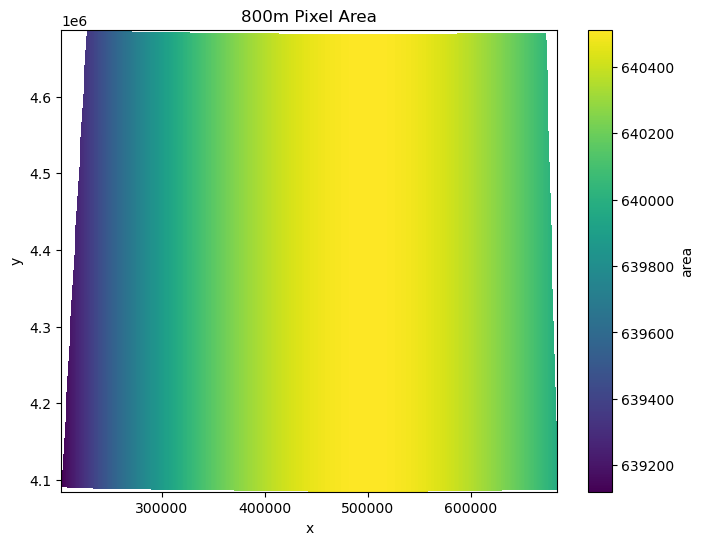

In [33]:
plt.figure(figsize=(8, 6))
area_ds['area'].plot(cmap='viridis')
plt.title('800m Pixel Area')
plt.show()

120404160.0
1.2040416e+08


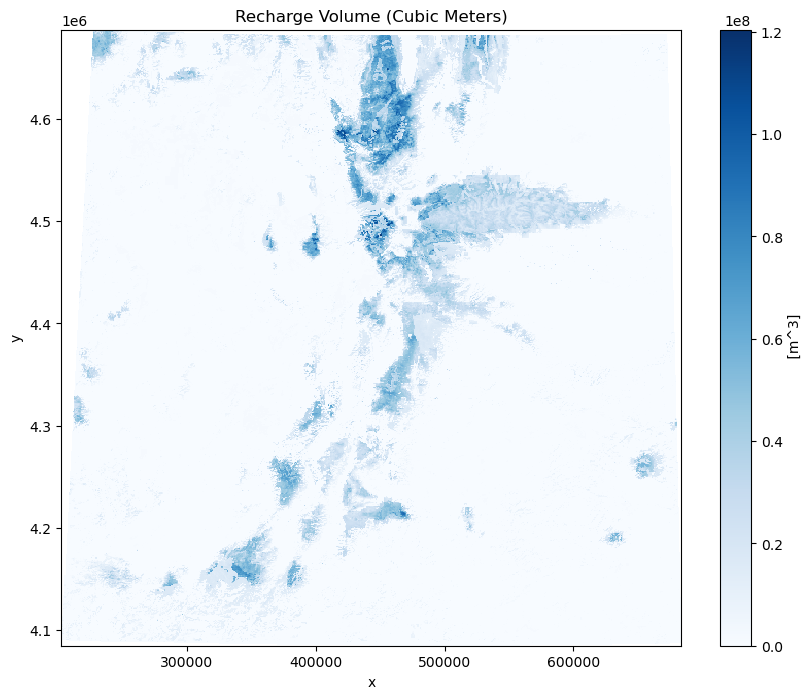

In [76]:
recharge_volume = prism800_DISALEXI_image * area_ds['area']
recharge_volume = recharge_volume.assign_attrs({'units': 'm^3'})
print(float(recharge_volume.max()))
print(recharge_volume.max().values)

# ---------------------------------------------------------
# STEP 5: Visualize
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))
# robust=True automatically stretches the color map, similar to GEE's min/max visualizer
recharge_volume.plot(cmap='Blues', robust=True, vmax=float(recharge_volume.max()))
plt.title(f'Recharge Volume (Cubic Meters)')
plt.show()

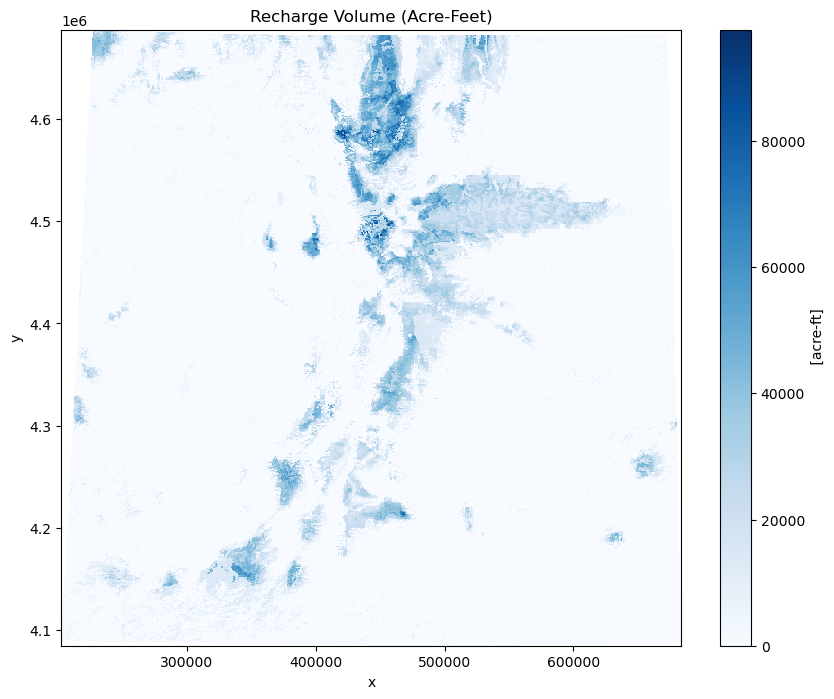

In [78]:
recharge_volume_acreft = (recharge_volume / 1233.48).assign_attrs({'units': 'acre-ft'})
plt.figure(figsize=(10, 8))
# robust=True automatically stretches the color map, similar to GEE's min/max visualizer
recharge_volume_acreft.plot(cmap='Blues', robust=True, vmax=float(recharge_volume_acreft.max()))
plt.title(f'Recharge Volume (Acre-Feet)')
plt.show()